# pre-final

In [2]:
# =========================================
# FULL PIPELINE: RF (label) -> Bin-wise XGB (first_pooling)
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

1) Chuẩn bị & quy tắc tiền xử lý

Mục đích: chuẩn hóa dữ liệu đầu vào đúng rule dự án để mô hình nhận các biến nhất quán.

Điền label trống → CANCELLED và driver_fee trống → 0.

Tạo epd_value theo rule service + region + ngưỡng giờ 16h (SAMEDAY/SAMEPRICE × HAN/SGN).

Tạo MPD theo rule (đơn vị đồng/km, âm để thể hiện “chi phí theo km”).

Tính margin = MPD * distance + driver_fee (xấp xỉ lợi nhuận sau “chi phí theo km” + phí tài xế).

Tạo is_internal = 1(margin > partner_fee) (đơn nào margin “ăn” tốt hơn giá đối tác thì coi là nội bộ).

Vì sao: Các biến này gói gọn chính sách vận hành/giá cước → tăng khả năng mô hình nắm bắt logic thật sự của hệ thống thay vì chỉ dựa vào tín hiệu yếu.

In [4]:
# ============== 1) Đọc & chuẩn hoá dữ liệu theo rule ==============
DATA_PATH = "/content/data_v9.csv"
df = pd.read_csv(DATA_PATH)

# Bổ sung các cột theo hướng dẫn (nếu thiếu)
df['label'] = df['label'].fillna('CANCELLED')
df['driver_fee'] = df['driver_fee'].fillna(0)

def epd(row):
    if row['service'] == 'SAMEDAY':
        if row['region'] == 'HAN':
            return 6.6 if row['hour'] < 16 else 5.6
        elif row['region'] == 'SGN':
            return 6.1 if row['hour'] < 16 else 5.0
    elif row['service'] == 'SAMEPRICE':
        if row['region'] == 'HAN':
            return 4.5 if row['hour'] < 16 else 5.0
        elif row['region'] == 'SGN':
            return 4.0 if row['hour'] < 16 else 5.0
    return np.nan

def mpd(row):
    if row['service'] == 'SAMEDAY':
        if row['region'] == 'HAN': return -300
        elif row['region'] == 'SGN': return -200
    elif row['service'] == 'SAMEPRICE':
        if row['region'] in ['HAN','SGN']: return -500
    return np.nan

if 'epd_value' not in df.columns:
    df['epd_value'] = df.apply(epd, axis=1)
if 'MPD' not in df.columns:
    df['MPD'] = df.apply(mpd, axis=1)

df['margin'] = df['MPD'] * df['distance'] + df['driver_fee']
df['is_internal'] = (df['margin'] > df['partner_fee']).astype(int)

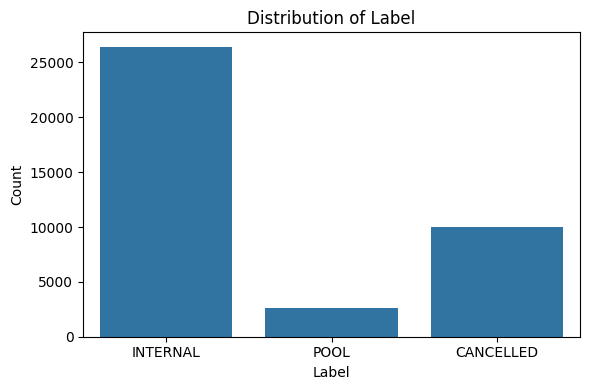

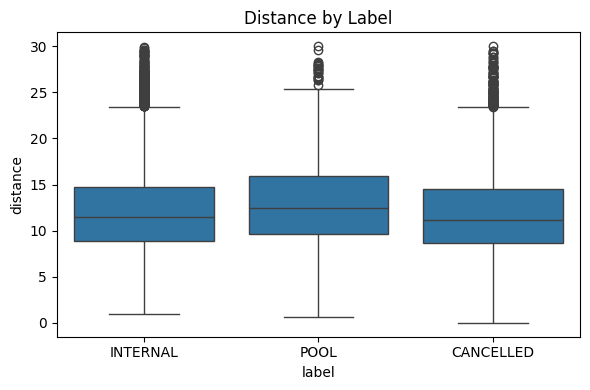

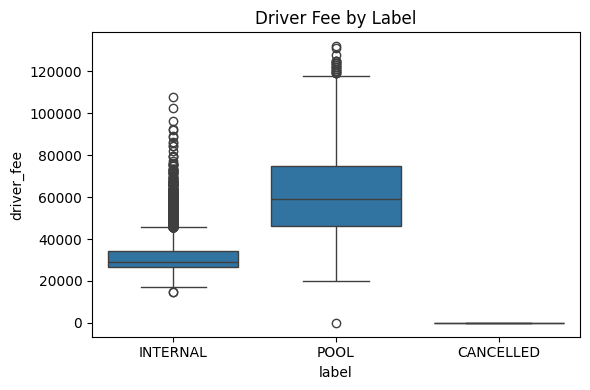

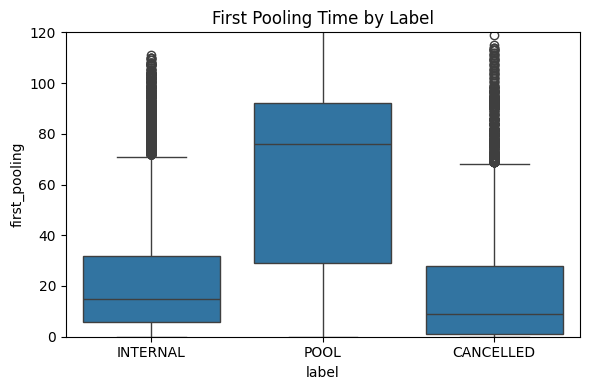

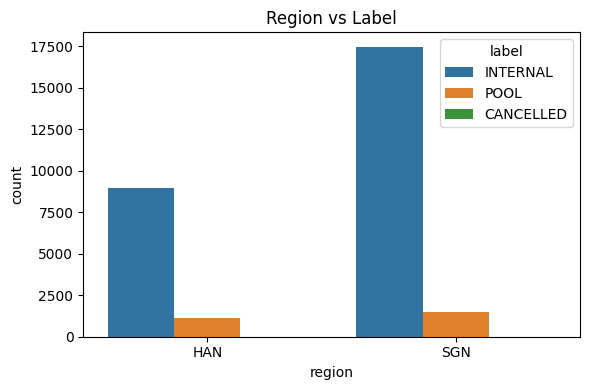

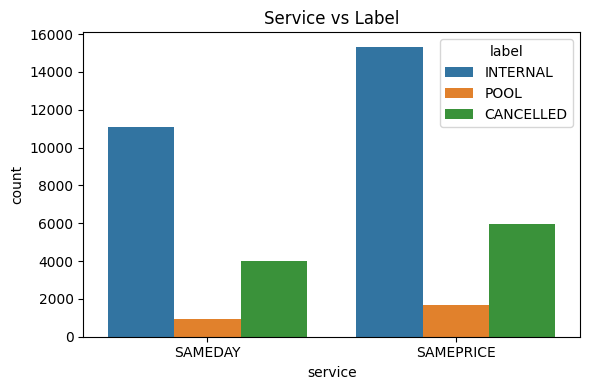

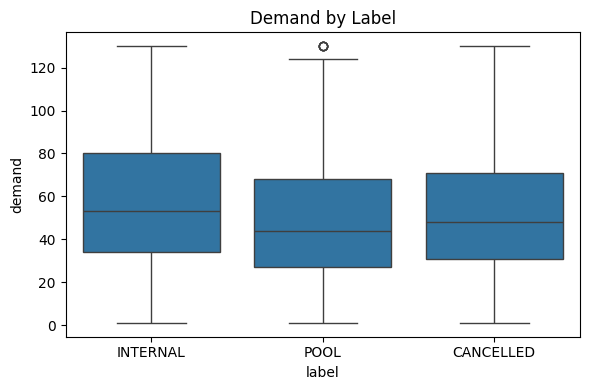

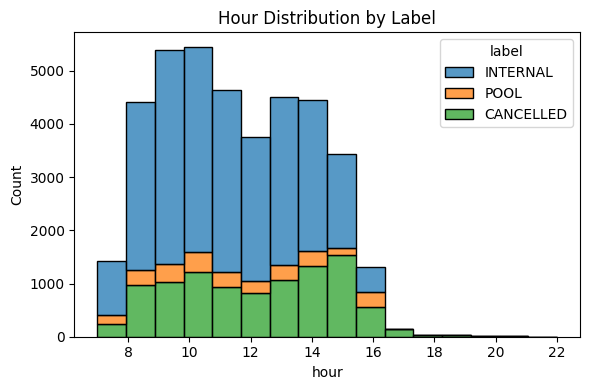

In [5]:
# Re-import libraries after reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Phân bố nhãn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title("Distribution of Label")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

# 2. Distance theo Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='label', y='distance')
plt.title("Distance by Label")
plt.tight_layout()
plt.show()

# 3. Driver fee theo Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='label', y='driver_fee')
plt.title("Driver Fee by Label")
plt.tight_layout()
plt.show()

# 4. First pooling theo Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='label', y='first_pooling')
plt.title("First Pooling Time by Label")
plt.ylim(0,120)  # zoom in để tránh outlier che mất phân bố chính
plt.tight_layout()
plt.show()

# 5. Region vs Label
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='region', hue='label')
plt.title("Region vs Label")
plt.tight_layout()
plt.show()

# 6. Service vs Label
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='service', hue='label')
plt.title("Service vs Label")
plt.tight_layout()
plt.show()

# 7. Demand theo Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='label', y='demand')
plt.title("Demand by Label")
plt.tight_layout()
plt.show()

# 8. Hour theo Label
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='hour', hue='label', multiple='stack', bins=16)
plt.title("Hour Distribution by Label")
plt.tight_layout()
plt.show()


2) Chọn biến & tiền xử lý chung

selected_features gồm 15 biến chính:
pickup_district, dropoff_district, distance, hour, service, region, driver_fee, partner_fee, weekday_number, demand, epd_value, MPD, margin, is_internal, buoi.

preprocessor (dùng cho cả classification & regression):

Categorical (pickup_district, dropoff_district, service, region, buoi):

SimpleImputer(most_frequent) → chống NaN

OneHotEncoder(handle_unknown='ignore') → mã hóa rời rạc, an toàn khi xuất hiện nhãn mới

Numeric (các biến còn lại):

SimpleImputer(median) → chống NaN, robust với lệch

StandardScaler() → chuẩn hóa thang đo (không bắt buộc với cây, nhưng có lợi khi đi cùng pipeline chung)

Vì sao: Với dữ liệu có missing + nhiều category, dùng Pipeline + ColumnTransformer giúp bạn đóng gói sạch toàn bộ xử lý và đảm bảo train/test dùng đúng biến đổi như nhau.

In [6]:
# ============== 2) Định nghĩa features & preprocessor dùng chung ==============
selected_features = [
    'pickup_district','dropoff_district',
    'distance','hour','service','region',
    'driver_fee','partner_fee',
    'weekday_number','demand',
    'epd_value','MPD','margin','is_internal','buoi'
]

categorical_cols = ['pickup_district','dropoff_district','service','region','buoi']
numeric_cols = [c for c in selected_features if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols),
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
    ],
    remainder='drop'
)

3) Model 1 — RandomForest Classification (dự đoán label)

Luồng:

Train/test split 80/20 với stratify=y_cls để giữ phân bố lớp (INTERNAL / POOL / CANCELLED).

Pipeline = preprocessor → RandomForestClassifier(n_estimators=300, n_jobs=-1).

Đánh giá:

classification_report (precision/recall/F1 theo lớp, macro-F1)

confusion_matrix

Dự đoán pred_label cho toàn bộ dữ liệu (không chỉ test). Lưu predictions_label_rf.csv.

Vì sao chọn RF:

Mạnh với dữ liệu tabular, chịu được biến rời rạc sau OHE, ít cần chuẩn hóa số liệu.

Dễ tăng/giảm độ phức tạp qua n_estimators, max_depth.

Mục đích kiến trúc:

Ở production, bạn không biết label thật. Vì vậy pipeline luôn dùng pred_label để quyết định bước hồi quy tiếp theo (đã mô phỏng đúng bằng cách dự đoán cho toàn bộ).

In [7]:
# ============== 3) MODEL 1 — Random Forest Classification (label) ==============
X_cls = df[selected_features].copy()
y_cls = df['label'].copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

rf_clf = Pipeline(steps=[
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)

print("\n=== [MODEL 1] RandomForest — Classification (label) ===")
print(classification_report(y_test_c, y_pred_c, digits=4))
macro_f1 = f1_score(y_test_c, y_pred_c, average='macro')
print(f"Macro-F1: {macro_f1:.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test_c, y_pred_c))

# Thêm cột label dự đoán toàn bộ để mô phỏng pipeline thực tế
df['pred_label'] = rf_clf.predict(X_cls)

# Xuất dự đoán phân loại
pred_cls_out = df[['order_id', 'label', 'pred_label']].copy()
pred_cls_out.to_csv("predictions_label_rf.csv", index=False)
print("\n-> Đã lưu dự đoán phân loại:", Path('predictions_label_rf.csv').resolve())


=== [MODEL 1] RandomForest — Classification (label) ===
              precision    recall  f1-score   support

   CANCELLED     0.9995    1.0000    0.9997      1992
    INTERNAL     0.9889    0.9943    0.9916      5285
        POOL     0.9395    0.8859    0.9119       526

    accuracy                         0.9885      7803
   macro avg     0.9760    0.9601    0.9678      7803
weighted avg     0.9883    0.9885    0.9883      7803

Macro-F1: 0.9678
Confusion matrix:
 [[1992    0    0]
 [   0 5255   30]
 [   1   59  466]]

-> Đã lưu dự đoán phân loại: /content/predictions_label_rf.csv


4) Model 2 — Bin-wise Regression (dự đoán first_pooling có ràng buộc khoảng)

Ý tưởng cốt lõi: thay vì dự đoán trực tiếp 0–∞ phút (khó, lệch phải, nhiều outlier), ta chia nhỏ bài toán:

Xếp mỗi đơn vào bin 15 phút dựa trên first_pooling (ground truth, chỉ dùng để TRAIN mỗi bin):

Bins: [0–15), [15–30), [30–45), [45–60), [60–90), [90–120), [120+)

Với mỗi bin, train một mô hình hồi quy riêng (XGBRegressor).

Khi dự đoán, ta clip kết quả về đúng khoảng của bin đó (giảm lỗi outlier).

Luồng chi tiết trong code:

Lọc dữ liệu hợp lệ cho hồi quy: (pred_label != 'CANCELLED') & first_pooling.notna()
→ mô phỏng đúng pipeline thực tế (đơn bị dự đoán CANCELLED sẽ không dự đoán pooling).

Tạo fp_bin từ first_pooling thật (chỉ để chia dữ liệu train theo nhóm).

Với mỗi bin (đủ mẫu, mặc định ≥200 để đảm bảo học ổn định):

Split 80/20 (riêng trong bin).

Pipeline: preprocessor → XGBRegressor(tree_method='hist', n_estimators=200, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, n_jobs=-1).

Dự đoán test của bin đó, np.clip(y_hat, lo, hi) để đảm bảo tuân thủ khoảng thời gian bin.

Lưu lại dự đoán và tính MAE/RMSE/R² cho từng bin.

Gộp toàn bộ test của các bin để tính Overall MAE/RMSE/R² (bạn đã thấy Overall R² cao hẳn so với 1‑step regression).

Ghi predictions_first_pooling_binwise.csv với:

order_id, bin, first_pooling_true, first_pooling_pred.


=== Per-bin metrics (clip trong khoảng) ===
   bin  n_test    range   MAE  RMSE     R2
  0-15    2715   [0,15) 3.530 4.171  0.025
 15-30    1245  [15,30) 3.697 4.328 -0.020
 30-45     658  [30,45) 3.758 4.353  0.004
 45-60     430  [45,60) 3.834 4.442  0.021
 60-90     525  [60,90) 6.556 7.947  0.077
90-120     241 [90,120) 3.017 4.750  0.478

=== OVERALL (gộp tất cả bin) ===
MAE:  3.866 phút
RMSE: 4.731 phút
R²:   0.9672

-> Đã lưu: /content/predictions_first_pooling_binwise.csv


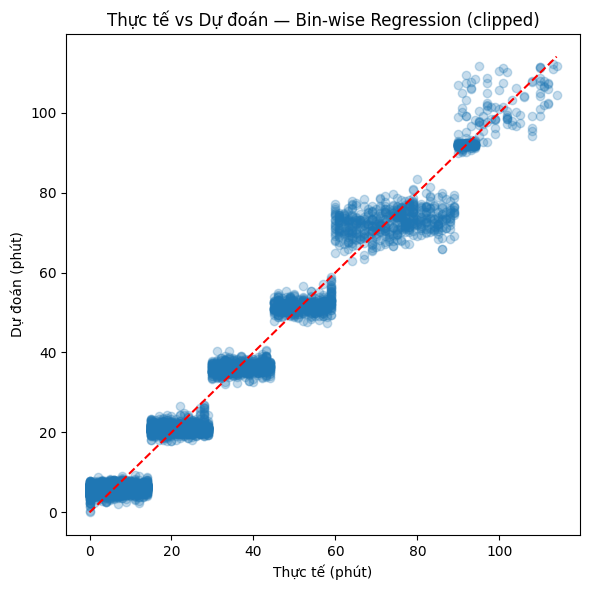

In [8]:
# ============== 4) MODEL 2 — Bin-wise Regression (clip theo khoảng) ==============
# 4.1 Chỉ giữ các đơn KHÔNG CANCELLED theo label DỰ ĐOÁN + có first_pooling
df_work = df[(df['pred_label'] != 'CANCELLED') & df['first_pooling'].notna()].copy()

# 4.2 Định nghĩa bin 15 phút và gán bin theo ground-truth (để train từng mô hình)
bin_edges  = [0, 15, 30, 45, 60, 90, 120, np.inf]
bin_labels = ['0-15','15-30','30-45','45-60','60-90','90-120','120+']

df_work['fp_bin'] = pd.cut(
    df_work['first_pooling'].astype(float),
    bins=bin_edges, right=False, labels=bin_labels
)
df_work = df_work[~df_work['fp_bin'].isna()].copy()

# 4.3 Preprocessor (dùng chung ở trên) & huấn luyện từng bin
per_bin_metrics = []
y_true_all, y_pred_all = [], []
pred_rows = []

for lbl in bin_labels:
    sub = df_work[df_work['fp_bin'] == lbl].copy()
    if sub.empty or len(sub) < 200:  # hạ ngưỡng nếu cần
        continue

    lo = bin_edges[bin_labels.index(lbl)]
    hi = bin_edges[bin_labels.index(lbl) + 1]
    clip_low, clip_high = lo, (hi - 1e-6 if np.isfinite(hi) else np.inf)

    X = sub[selected_features]
    y = sub['first_pooling'].astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    model = Pipeline(steps=[
        ('prep', preprocessor),
        ('xgb', XGBRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.08,
            subsample=0.9, colsample_bytree=0.9,
            tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE
        ))
    ])

    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)
    y_hat = np.clip(y_hat, clip_low, clip_high)  # ràng buộc trong khoảng

    # Metrics per bin
    mae_b  = mean_absolute_error(y_te, y_hat)
    rmse_b = rmse(y_te, y_hat)
    r2_b   = r2_score(y_te, y_hat)

    per_bin_metrics.append({
        'bin': lbl, 'n_test': len(y_te),
        'range': f"[{clip_low},{'∞' if not np.isfinite(hi) else int(hi)})",
        'MAE': mae_b, 'RMSE': rmse_b, 'R2': r2_b
    })

    # Gộp để tính overall
    y_true_all.append(y_te.values)
    y_pred_all.append(y_hat)

    # Lưu dự đoán để export
    out_df = pd.DataFrame({
        'order_id': sub.loc[X_te.index, 'order_id'].values,
        'bin': lbl,
        'first_pooling_true': y_te.values,
        'first_pooling_pred': y_hat
    })
    pred_rows.append(out_df)

# 4.4 Tổng hợp & in kết quả
if len(y_true_all) == 0:
    raise RuntimeError("Không có bin nào đủ dữ liệu để train.")

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

overall_mae  = mean_absolute_error(y_true_all, y_pred_all)
overall_rmse = rmse(y_true_all, y_pred_all)
overall_r2   = r2_score(y_true_all, y_pred_all)

print("\n=== Per-bin metrics (clip trong khoảng) ===")
per_bin_table = pd.DataFrame(per_bin_metrics).sort_values('bin')
print(per_bin_table.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

print("\n=== OVERALL (gộp tất cả bin) ===")
print(f"MAE:  {overall_mae:.3f} phút")
print(f"RMSE: {overall_rmse:.3f} phút")
print(f"R²:   {overall_r2:.4f}")

# 4.5 Xuất dự đoán (bin-wise)
pred_all = pd.concat(pred_rows, ignore_index=True)
pred_path = Path("predictions_first_pooling_binwise.csv")
pred_all.to_csv(pred_path, index=False)
print("\n-> Đã lưu:", pred_path.resolve())

# (Tuỳ chọn) Vẽ scatter kiểm tra
try:
    plt.figure(figsize=(6,6))
    plt.scatter(y_true_all, y_pred_all, alpha=0.25)
    lims = [min(y_true_all.min(), y_pred_all.min()), max(y_true_all.max(), y_pred_all.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Thực tế (phút)")
    plt.ylabel("Dự đoán (phút)")
    plt.title("Thực tế vs Dự đoán — Bin-wise Regression (clipped)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Skip plot:", e)


In [12]:
# ===================== SUMMARY FEATURES BY BIN (NO caas_jupyter_tools) =====================
# Các feature dùng trong model
selected_features = [
    'pickup_district','dropoff_district',
    'distance','hour','service','region',
    'driver_fee','partner_fee',
    'weekday_number','demand',
    'epd_value','MPD','margin','is_internal','buoi'
]

# 1) Numeric summary theo bin (mean)
numeric_cols_for_summary = [
    'distance','hour','driver_fee','partner_fee','weekday_number',
    'demand','epd_value','MPD','margin','is_internal'
]
numeric_summary = (
    df_work
    .groupby('fp_bin')[numeric_cols_for_summary]
    .mean()
    .round(2)
    .reindex(bin_labels)      # đảm bảo đúng thứ tự bin
)
print("\n=== NUMERIC SUMMARY (mean) BY BIN ===")
print(numeric_summary)
numeric_summary.to_csv("bin_numeric_summary.csv", index=True)

# 2) Phân bố categorical theo bin: count & %
def dist_count_pct(df, by_col):
    ct = df.groupby(['fp_bin', by_col]).size().unstack(fill_value=0)
    ct = ct.reindex(bin_labels)  # sắp xếp bin
    pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
    return ct, pct

service_count, service_pct = dist_count_pct(df_work, 'service')
region_count,  region_pct  = dist_count_pct(df_work, 'region')
buoi_count,    buoi_pct    = dist_count_pct(df_work, 'buoi')

print("\n=== SERVICE DISTRIBUTION — COUNT BY BIN ===")
print(service_count)
print("\n=== SERVICE DISTRIBUTION — PERCENT (%) BY BIN ===")
print(service_pct)

print("\n=== REGION DISTRIBUTION — COUNT BY BIN ===")
print(region_count)
print("\n=== REGION DISTRIBUTION — PERCENT (%) BY BIN ===")
print(region_pct)

print("\n=== BUOI DISTRIBUTION — COUNT BY BIN ===")
print(buoi_count)
print("\n=== BUOI DISTRIBUTION — PERCENT (%) BY BIN ===")
print(buoi_pct)

service_count.to_csv("bin_service_count.csv")
service_pct.to_csv("bin_service_pct.csv")
region_count.to_csv("bin_region_count.csv")
region_pct.to_csv("bin_region_pct.csv")
buoi_count.to_csv("bin_buoi_count.csv")
buoi_pct.to_csv("bin_buoi_pct.csv")

# 3) Top-N pickup/dropoff_district theo bin
def top_n_cat_by_bin(df, cat_col, n=5):
    out_rows = []
    for b in bin_labels:
        sub = df[df['fp_bin'] == b]
        if sub.empty:
            continue
        vc = sub[cat_col].value_counts().head(n)
        for k, v in vc.items():
            out_rows.append({'bin': b, cat_col: k, 'count': v})
    out = pd.DataFrame(out_rows)
    return out

top5_pickup  = top_n_cat_by_bin(df_work, 'pickup_district', n=5)
top5_dropoff = top_n_cat_by_bin(df_work, 'dropoff_district', n=5)

print("\n=== TOP-5 PICKUP DISTRICT BY BIN ===")
print(top5_pickup)
print("\n=== TOP-5 DROPOFF DISTRICT BY BIN ===")
print(top5_dropoff)

top5_pickup.to_csv("bin_top5_pickup_district.csv", index=False)
top5_dropoff.to_csv("bin_top5_dropoff_district.csv", index=False)

# 4) Gói tất cả đường dẫn file để tiện xem
print("\n--> Saved:")
print("- bin_numeric_summary.csv")
print("- bin_service_count.csv ; bin_service_pct.csv")
print("- bin_region_count.csv  ; bin_region_pct.csv")
print("- bin_buoi_count.csv    ; bin_buoi_pct.csv")
print("- bin_top5_pickup_district.csv ; bin_top5_dropoff_district.csv")
# ===================== END SUMMARY =====================



=== NUMERIC SUMMARY (mean) BY BIN ===
        distance   hour  driver_fee  partner_fee  weekday_number  demand  \
fp_bin                                                                     
0-15       11.52  11.25    31614.01     28674.50            5.91   58.25   
15-30      12.10  11.05    31482.31     28394.79            5.92   58.93   
30-45      12.54  11.00    32686.80     28515.97            5.95   56.03   
45-60      12.95  10.79    33618.24     28265.61            5.97   53.02   
60-90      13.40  10.88    38686.14     28447.37            6.00   51.34   
90-120     14.87  10.79    63500.47     27807.47            6.07   50.00   
120+       11.04  10.00    51000.00     25000.00            6.00   47.00   

        epd_value     MPD    margin  is_internal  
fp_bin                                            
0-15         5.15 -376.34  27224.27         0.26  
15-30        5.02 -386.85  26692.66         0.26  
30-45        4.95 -391.72  27617.03         0.30  
45-60        4.84 -40

In [9]:
# ===== 6) Gộp dự đoán vào dataframe gốc =====
# Chỉ merge cho các đơn không CANCELLED (theo dự đoán Model 1) và có trong pred_all
final_df = df.merge(pred_all, on='order_id', how='left')
final_df
# # Xuất file đầy đủ
# final_path = Path("final_predictions_all.csv")
# final_df.to_csv(final_path, index=False)
# print("\n-> Đã lưu file dự đoán cuối cùng:", final_path.resolve())


,order_date,order_id,pickup_district,dropoff_district,distance,parent_service_id,hour,service,pooling_internal,total_pooling,...,weekday_number,demand,epd_value,MPD,margin,is_internal,pred_label,bin,first_pooling_true,first_pooling_pred
0,7/18/2025,25F7L7TT,Quận Hai Bà Trưng,Quận Hà Đông,14.41,HAN-SAMEDAY-INTERNAL,10,SAMEDAY,3,3,...,6,62,6.6,-300.0,27475.20,0,INTERNAL,NaN,NaN,NaN
1,7/18/2025,25GOSZ2J,Quận Long Biên,Quận Hoàn Kiếm,4.71,HAN-SAMEDAY-INTERNAL,8,SAMEDAY,3,3,...,6,44,6.6,-300.0,22553.00,0,INTERNAL,0-15,4.0,6.210494
2,7/18/2025,25ROFAPU,Quận Nam Từ Liêm,Quận Nam Từ Liêm,7.85,HAN-SAMEDAY-INTERNAL,9,SAMEDAY,1,1,...,6,81,6.6,-300.0,34831.67,1,INTERNAL,NaN,NaN,NaN
3,7/18/2025,25OAIKPP,Quận Long Biên,Quận Hà Đông,15.31,HAN-POOL,16,SAMEDAY,2,3,...,6,26,5.6,-300.0,71407.00,1,POOL,NaN,NaN,NaN
4,7/18/2025,25PDWCKX,Quận Hai Bà Trưng,Quận Nam Từ Liêm,9.52,HAN-SAMEDAY-INTERNAL,9,SAMEDAY,2,2,...,6,50,6.6,-300.0,22536.00,0,INTERNAL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39010,7/17/2025,25VK6OGL,Quận 7,Quận 5,10.75,SGN-SAMEDAY-INTERNAL,14,SAMEPRICE,1,1,...,5,46,4.0,-500.0,19845.57,0,INTERNAL,0-15,5.0,5.978585
39011,7/17/2025,25PEYQF8,Huyện Hóc Môn,Quận 8,21.67,SGN-SAMEDAY-INTERNAL,10,SAMEPRICE,1,1,...,5,54,4.0,-500.0,24246.14,0,INTERNAL,NaN,NaN,NaN
39012,7/17/2025,25TXOPM3,Quận 6,Quận 7,14.65,SGN-SAMEDAY-INTERNAL,9,SAMEPRICE,1,1,...,5,17,4.0,-500.0,19814.56,0,INTERNAL,NaN,NaN,NaN
39013,7/17/2025,25IRINBM,Huyện Bình Chánh,Huyện Hóc Môn,15.39,SGN-POOL,14,SAMEPRICE,0,2,...,5,40,4.0,-500.0,61305.00,1,POOL,NaN,NaN,NaN
